# Simulation of LUCJ circuits

In [3]:
import ffsim
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf

import qiskit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.transpiler import CouplingMap
from qiskit.quantum_info import Statevector, SparsePauliOp

## Parameters

In [4]:
atom: str = "H"
natoms: int = 6
nlayers: int = 2  # Number of layers in the ansatz.

## Problem defintion

### Molecule

In [5]:
def generate_linear_geometry(atom: str, natoms: int, atomic_distance: float = 1.0) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.
    
    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"{atom} 0 0 {i * atomic_distance}" for i in range(natoms)])

In [6]:
# Specify molecule properties
spin_sq = 0

# Build N2 molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=generate_linear_geometry(atom, natoms),
    basis="sto-6g",
)

# Define active space
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

# Compute exact energy using FCI
# reference_energy = cas.run().e_tot

print(f"norb = {norb}")
print(f"nelec = {nelec}")

converged SCF energy = -3.15600092954731
norb = 6
nelec = (3, 3)


## Circuit construction

In [7]:
# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

E(CCSD) = -3.257214530748513  E_corr = -0.1012136012012061


In [8]:
coupling_map = CouplingMap.from_grid(
    num_rows=int(np.ceil(np.sqrt(2 * norb))),
    num_columns=int(np.ceil(np.sqrt(2 * norb)))
)
backend = GenericBackendV2(
    coupling_map.size(),
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

In [9]:
pairs_aa = [(p, p + 1) for p in range(norb - 1)]
pairs_ab = [(p, p) for p in range(norb)]  # None  # Let generate_lucj_pass_manager determine the alpha-beta interactions

In [10]:
# Create pass manager
try:
    pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend,
        norb=norb,
        connectivity="square",
        interaction_pairs=(pairs_aa, pairs_ab),
        optimization_level=3,
    )
    print("Unable to generate ffsim pass manager")
except RuntimeError:
    pass_manager = None

print("pairs_aa:", pairs_aa)
print("pairs_ab:", pairs_ab)

/home/lonelyneutrin0/Repos/propaq/venv/lib/python3.12/site-packages/ffsim/qiskit/lucj_pass_manager.py:160: UserWarning: Backend cannot accommodate pairs_ab=[(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5)].
Removing interaction (5, 5) from the end.
  warnings.warn(
/home/lonelyneutrin0/Repos/propaq/venv/lib/python3.12/site-packages/ffsim/qiskit/lucj_pass_manager.py:160: UserWarning: Backend cannot accommodate pairs_ab=[(0, 0), (1, 1), (2, 2), (3, 3), (4, 4)].
Removing interaction (4, 4) from the end.
  warnings.warn(


Unable to generate ffsim pass manager
pairs_aa: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5)]
pairs_ab: [(0, 0), (1, 1), (2, 2), (3, 3)]


In [11]:
# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=nlayers,
    interaction_pairs=(pairs_aa, pairs_ab),
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    # Limit the number of optimization iterations to prevent the code cell from running
    # too long. Removing this line may improve results.
    # options=dict(maxiter=1000),
)

qubits = qiskit.QuantumRegister(2 * norb, name="q")
circuit = qiskit.QuantumCircuit(qubits)
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)

In [12]:
if pass_manager is not None:
    compiled = pass_manager.run(circuit)
else:
    compiled = qiskit.transpile(circuit, backend=backend, optimization_level=3)

In [13]:
print(f"Number of qubits: {compiled.num_qubits}")
print(f"Gate counts: {compiled.count_ops()}")

Number of qubits: 16
Gate counts: OrderedDict({'xx_plus_yy': 78, 'cp': 28, 'p': 24, 'x': 6})


In [14]:
compiled.draw(fold=-1)

┌───┐                                                       ┌────────────────────────┐                                                                                                                                                                                                                                                                                                         ┌─────────────────────────┐                                                            ┌──────────────────────────┐                                                                                     ┌─────────────────────────┐       ┌────────────┐                                                                                                                                                                                                                                          ┌──────────────────────────┐                                                                                     ┌──────────────────────────┐                                                                                    ┌─────────────────────────┐        ┌───────────┐                                                                                                                                                                       
  q_0 -> 1 ┤ X ├───────────────────────────────────────────────────────┤1                       ├──────────────────────────────────────────────────────────────────────────────────────────■────────────────────────────────────────────────────────────────────────■─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤1                        ├────────────────────────────────────────────────────────────┤1                         ├─────────────────────────────────────────────────────────────────────────────────────┤1                        ├───────┤ P(-1.0753) ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────■─────────────────────────────────────────────────■───────────────────────────────────────────────────────┤1                         ├─────────────────────────────────────────────────────────────────────────────────────┤1                         ├────────────────────────────────────────────────────────────────────────────────────┤1                        ├────────┤ P(1.8346) ├───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
           ├───┤                                                       │                        │  ┌────────────────────────┐                                                              │                                                                        │P(-0.48526)                                                                                                                          │                         │ ┌─────────────────────────┐                                │                          │ ┌──────────────────────────┐                                                        │                         │┌──────┴────────────┴─────┐        ┌────────────┐                                                                                                    │                                                 │P(0.48526)                                             │                          │┌──────────────────────────┐                                                         │                          │┌──────────────────────────┐                                                        │                         │ ┌──────┴───────────┴──────┐         ┌───────────┐                                                                                                                                          
  q_6 -> 2 ┤ X ├────────────────────────────────────────────

## Observable definition

In [15]:
observables = [
    SparsePauliOp("ZZ" + "I" * (compiled.num_qubits - 2)),
    SparsePauliOp("I" * (compiled.num_qubits // 2) + "ZZ" + "I" * (compiled.num_qubits // 2 - 2)),
    SparsePauliOp("I" * (compiled.num_qubits - 2) + "ZZ")
]

## Exact values

In [16]:
if compiled.num_qubits <= 20:
    expectation_values_exact = []
    for observable in observables:
        statevector = Statevector(compiled)
        sv_expectation_value = statevector.expectation_value(observable).real
        print(sv_expectation_value)
        expectation_values_exact.append(sv_expectation_value)

0.8568330070658419
-0.978438613207943
-0.8068049814271874


## Heisenberg simulation

In [17]:
from propaq.datatypes import PauliString

from propaq.propagators import PauliPropagator
from propaq.circuits import PauliCircuit 
from propaq.noise import UniformNoiseModel
from propaq.noise import TruncationPolicy 

from propaq.datatypes import PauliTermSum

In [18]:
mc = PauliCircuit.from_qiskit(compiled.copy())

In [19]:
damping: float = 0.0000
cutoff: float = 1e-16
prop = PauliPropagator(
    UniformNoiseModel(damping=damping),
    TruncationPolicy(weight_cutoff=100000, coeff_cutoff=cutoff),
    n_threads=5,
    progress_bar=True,
)

In [20]:
results = []
for observable in observables:
    observable_mts = PauliTermSum.from_sparse_pauli_op(observable)
    results.append(prop.expectation_value(observable_mts, mc, fock_state=0))
    print(results[-1].expectation_value)

/home/lonelyneutrin0/Repos/propaq/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Propagating through gates:   0%|          | 1/426 [00:00<00:00, 659.69it/s, terms=1]

Propagating through gates: 100%|██████████| 426/426 [01:02<00:00,  6.80it/s, terms=3833393]  


0.856833007065835


Propagating through gates: 100%|██████████| 426/426 [00:26<00:00, 16.06it/s, terms=2941851]  


-0.9784386132079447


Propagating through gates: 100%|██████████| 426/426 [00:32<00:00, 12.98it/s, terms=3110084]  

-0.8068049814271935


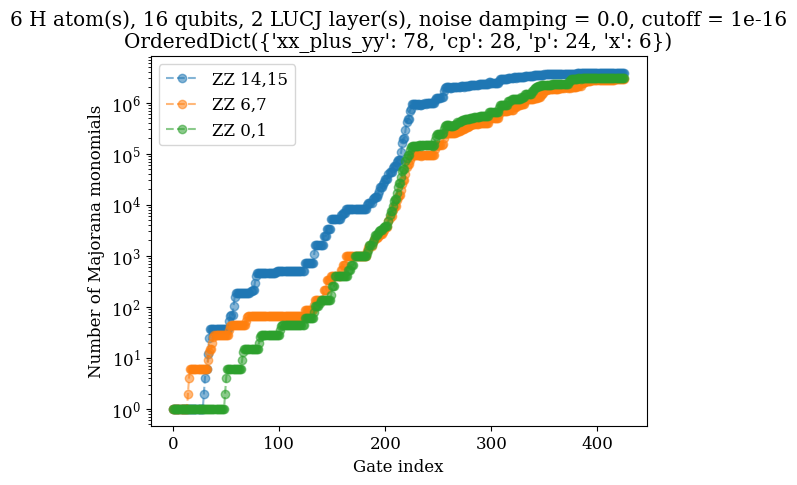

In [21]:
for i, result in enumerate(results):
    plt.semilogy(result.n_terms, "--o", alpha=0.55,label="ZZ " + ",".join(map(str, observables[i].to_sparse_list()[0][1])))

plt.xlabel("Gate index")
plt.ylabel("Number of Majorana monomials")
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s), noise damping = {damping}, cutoff = {cutoff}\n{compiled.count_ops()}")
plt.legend();

## Accuracy vs coefficient cutoff threshold

In [22]:
cutoffs = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
evals = []
for cutoff in cutoffs:
    print("On cutoff:", cutoff)
    prop = PauliPropagator(
        UniformNoiseModel(damping=0.00),
        TruncationPolicy(weight_cutoff=100000, coeff_cutoff=cutoff),
        n_threads=5,
        progress_bar=True,
    )
    oevals = []
    for i, observable in enumerate(observables):
        observable_mts = PauliTermSum.from_sparse_pauli_op(observable)
        mp_expectation_value = prop.expectation_value(observable_mts, mc, fock_state=0).expectation_value
        print(mp_expectation_value, expectation_values_exact[i])
        oevals.append(mp_expectation_value)
    evals.append(oevals)

On cutoff: 1e-09


Propagating through gates: 100%|██████████| 426/426 [00:28<00:00, 15.21it/s, terms=1950080]  


0.8568330580674245 0.8568330070658419


Propagating through gates: 100%|██████████| 426/426 [00:08<00:00, 51.94it/s, terms=1.2e+6]  


-0.9784386324909894 -0.978438613207943


...

-3.65063534957244e-12 0.8568330070658419


Propagating through gates: 100%|██████████| 426/426 [00:00<00:00, 1633.43it/s, terms=3]


-0.8071706052114631 -0.978438613207943


Propagating through gates: 100%|██████████| 426/426 [00:00<00:00, 1780.53it/s, terms=2] 

0.06372370629706436 -0.8068049814271874


In [23]:
evals = np.array(evals).T

errors = []
for i, e in enumerate(evals):
    errors.append(e - expectation_values_exact[i])

errors = np.abs(np.array(errors))

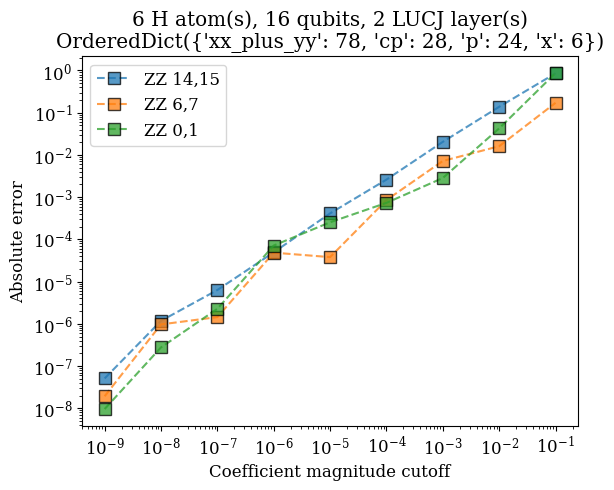

In [24]:
for i, e in enumerate(errors):
    plt.loglog(cutoffs, e, "--s", ms=9, mec="black", alpha=0.75, label="ZZ " + ",".join(map(str, observables[i].to_sparse_list()[0][1])))

plt.xlabel("Coefficient magnitude cutoff")
plt.ylabel(f"Absolute error")
plt.legend()
plt.title(f"{natoms} {atom} atom(s), {len(compiled.qubits)} qubits, {nlayers} LUCJ layer(s)\n{compiled.count_ops()}");
plt.savefig("error_vs_cutoff.pdf")